# PyPRIMAT — Standard Plots

## Schramm Diagram: Primordial Abundances vs. Baryon Density

This notebook illustrates the core output of PyPRIMAT: primordial abundances of
⁴He, D, ³He, and ⁷Li as a function of the baryon-to-photon ratio η_b.

**Shaded bands** show the combined nuclear rate uncertainty, obtained by a
Monte Carlo over all 12 reaction rates drawn simultaneously from N(0,1) log-normal
distributions. The band is the 1σ standard deviation across MC samples.

**Observational constraints** (grey bands):
- YP: Yeh et al. 2026 (arXiv:2601.22239) — 0.2458 ± 0.0013
- D/H: Cooke et al. 2018 — (2.527 ± 0.030) × 10⁻⁵
- ³He/⁴He: Cooke et al. 2026 (arXiv:2605.00122) — (1.15 ± 0.24) × 10⁻⁴
- ⁷Li/H: Sbordone et al. 2010 (Spite plateau) — (1.58 ± 0.31) × 10⁻¹⁰
- Vertical red band: Planck Ω_b h² = 0.02285 ± 0.00016

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from primat.main import PRIMAT, mc_uncertainty

In [2]:
# Single default run
opts_init = {
    "Omegabh2":          0.022425,
    "network":          "small",
}
result = PRIMAT(params=opts_init).primat_results()
print(result)

{'YPCMB': np.float64(0.24567136907553747), 'YPBBN': np.float64(0.24699767260018024), 'DoH': np.float64(2.4349902186626865e-05), 'He3oH': np.float64(1.039772304980051e-05), 'He3oHe4': np.float64(0.00012678474368517826), 'Li7oH': np.float64(5.561639548807278e-10), 'Neff': np.float64(3.0439772985579183), 'Omeganurel': np.float64(5.6986373185272265), 'OneOverOmeganunr': np.float64(93.04303400064333)}


## Schramm plot — central values

Scan η_b from 10⁻¹⁰ to 10⁻⁹ with all nuclear rates at their median values (p_* = 0).
The corresponding Ω_b h² is derived from the config conversion factor.
The weak rates are reused from the cache saved above.

In [3]:
from primat.config import PRIMATConfig

# Conversion factor η_b = Omegabh2_to_eta0b × Ω_b h²
_Omegabh2_to_eta0b = PRIMATConfig().Omegabh2_to_eta0b

npoints = 20
eta_vec      = np.logspace(-10, -9, npoints)
Omegabh2_vec = eta_vec / _Omegabh2_to_eta0b

# Reuse cached weak rates for all subsequent runs
base_opts = {
    "network":          "small",
}

YP_cen      = np.zeros(npoints)
DoH_cen     = np.zeros(npoints)
He3oHe4_cen = np.zeros(npoints)
Li7oH_cen   = np.zeros(npoints)

for i, ob2 in enumerate(Omegabh2_vec):
    r = PRIMAT(params={**base_opts, "Omegabh2": ob2}).primat_results()
    YP_cen[i]      = r['YPBBN']
    DoH_cen[i]     = r['DoH']
    He3oHe4_cen[i] = r['He3oH'] / (r['YPBBN'] / 4.)   # He3/He4 by number
    Li7oH_cen[i]   = r['Li7oH']

print("Central values done.")

Central values done.


## Nuclear rate uncertainty bands — Monte Carlo

At each Ω_b h² grid point we run `num_mc` iterations, drawing all 12 nuclear
rate sampling parameters `p_*` simultaneously from N(0,1). The 1σ standard
deviation across samples gives the uncertainty band.

All runs are parallelised over available CPUs via **joblib**.

In [4]:
import multiprocessing

num_mc  = 20    # increase for smoother bands (paper-quality: ~500)
num_cpu = multiprocessing.cpu_count()
print(f"Running {num_mc} MC iterations × {npoints} eta points "
      f"= {num_mc * npoints} jobs on {num_cpu} CPUs")

quantities = ['YPBBN', 'DoH', 'He3oH', 'Li7oH']

YP_err      = np.zeros(npoints)
DoH_err     = np.zeros(npoints)
He3oHe4_err = np.zeros(npoints)
Li7oH_err   = np.zeros(npoints)

# Same seed at every grid point: sample j draws the same p_* vector everywhere,
# so finite-MC bias is correlated across the grid and cancels when comparing points.
MC_SEED = 0

for i, ob2 in enumerate(Omegabh2_vec):
    opts = {**base_opts, "Omegabh2": ob2}
    mc = mc_uncertainty(num_mc, quantities, params=opts,
                        n_jobs=num_cpu, seed=MC_SEED)
    YP_err[i]    = mc['YPBBN'].std
    DoH_err[i]   = mc['DoH'].std
    Li7oH_err[i] = mc['Li7oH'].std
    He3oHe4_samples = mc['He3oH'].values / (mc['YPBBN'].values / 4.)
    He3oHe4_err[i]  = np.std(He3oHe4_samples)

print("MC bands done.")

Running 20 MC iterations × 20 eta points = 400 jobs on 8 CPUs
MC bands done.


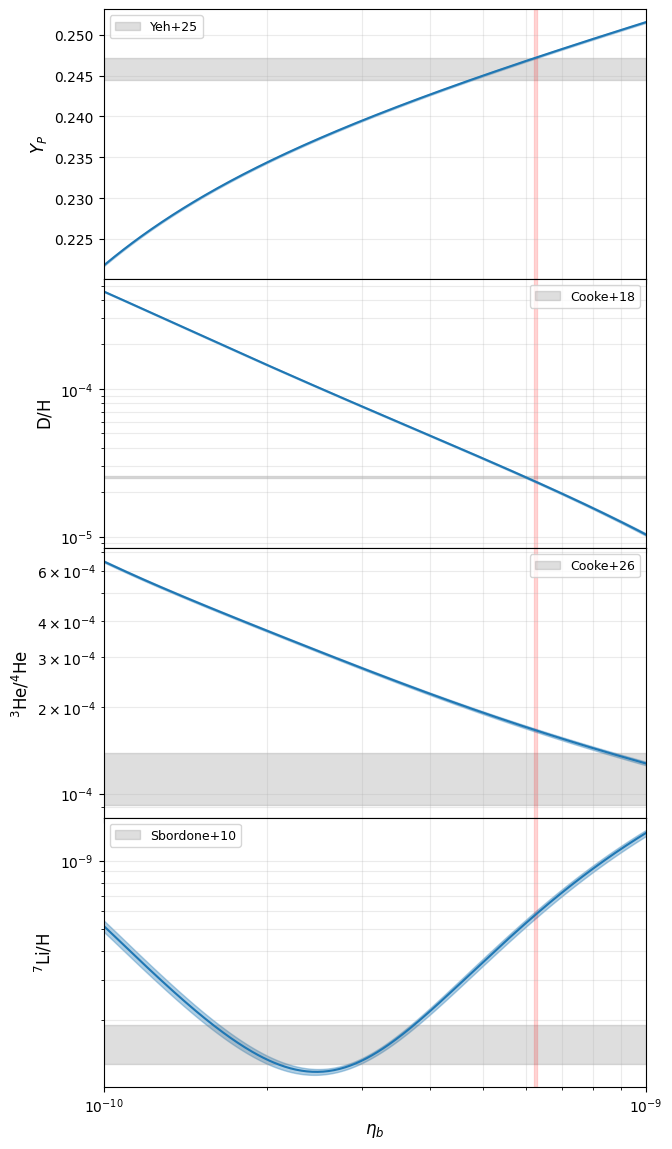

Saved schramm_plot.pdf


In [5]:
fig, axs = plt.subplots(4, 1, figsize=(7, 14), sharex=True)
fig.subplots_adjust(hspace=0)

x     = eta_vec
xfine = np.logspace(-10, -9, 300)

def smooth(y):
    return interp1d(x, y, kind='cubic')(xfine)

c_th  = 'tab:blue'
c_obs = 'tab:gray'

# Observational constraints (true ratios)
YP_obs,      YP_obs_err      = 0.2458,   0.0013      # Yeh et al. 2025 (arXiv:2601.22239)
DoH_obs,     DoH_obs_err     = 2.527e-5, 0.030e-5    # Cooke et al. 2018
He3oHe4_obs, He3oHe4_obs_err = 1.15e-4,  0.24e-4    # Cooke et al. 2026 (arXiv:2605.00122)
Li7_obs,     Li7_obs_err     = 1.58e-10, 0.31e-10    # Sbordone et al. 2010

# Planck Omegabh2 → eta_b
eta_planck     = 0.02285 * _Omegabh2_to_eta0b
eta_planck_err = 0.00016 * _Omegabh2_to_eta0b

def planck_band(ax):
    ax.axvspan(eta_planck - eta_planck_err, eta_planck + eta_planck_err,
               alpha=0.15, color='red')

# ---- YP ----
ax = axs[0]
ax.fill_between(xfine, smooth(YP_cen - YP_err), smooth(YP_cen + YP_err),
                alpha=0.35, color=c_th)
ax.plot(xfine, smooth(YP_cen), color=c_th, lw=1.5)
ax.axhspan(YP_obs - YP_obs_err, YP_obs + YP_obs_err,
           alpha=0.25, color=c_obs, label='Yeh+25')
ax.set_ylabel(r'$Y_P$', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
planck_band(ax)

# ---- D/H ----
ax = axs[1]
ax.fill_between(xfine, smooth(DoH_cen - DoH_err), smooth(DoH_cen + DoH_err),
                alpha=0.35, color=c_th)
ax.plot(xfine, smooth(DoH_cen), color=c_th, lw=1.5)
ax.axhspan(DoH_obs - DoH_obs_err, DoH_obs + DoH_obs_err,
           alpha=0.25, color=c_obs, label='Cooke+18')
ax.set_ylabel(r'${\rm D/H}$', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=9, loc='upper right')
planck_band(ax)

# ---- He3/He4 ----
ax = axs[2]
ax.fill_between(xfine, smooth(He3oHe4_cen - He3oHe4_err), smooth(He3oHe4_cen + He3oHe4_err),
                alpha=0.35, color=c_th)
ax.plot(xfine, smooth(He3oHe4_cen), color=c_th, lw=1.5)
ax.axhspan(He3oHe4_obs - He3oHe4_obs_err, He3oHe4_obs + He3oHe4_obs_err,
           alpha=0.25, color=c_obs, label='Cooke+26')
ax.set_ylabel(r'${}^3{\rm He}/{}^4{\rm He}$', fontsize=12)
ax.set_yscale('log')
ax.legend(fontsize=9, loc='upper right')
planck_band(ax)

# ---- 7Li/H ----
ax = axs[3]
ax.fill_between(xfine, smooth(Li7oH_cen - Li7oH_err), smooth(Li7oH_cen + Li7oH_err),
                alpha=0.35, color=c_th)
ax.plot(xfine, smooth(Li7oH_cen), color=c_th, lw=1.5)
ax.axhspan(Li7_obs - Li7_obs_err, Li7_obs + Li7_obs_err,
           alpha=0.25, color=c_obs, label='Sbordone+10')
ax.set_ylabel(r'${}^7{\rm Li/H}$', fontsize=12)
ax.set_yscale('log')
ax.set_xlabel(r'$\eta_b$', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
planck_band(ax)

# Shared x-axis formatting
for ax in axs:
    ax.set_xscale('log')
    ax.set_xlim(x[0], x[-1])
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=10)

plt.savefig('plots/schramm_plot.pdf', bbox_inches='tight')
plt.show()
print("Saved schramm_plot.pdf")